<a href="https://colab.research.google.com/github/enilt/langgraph-alura/blob/main/Aula_05_HITL_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 05 — Human-in-the-Loop (HITL) com LangGraph + Groq

Nesta aula o agente **pausa antes de executar uma ferramenta** e espera a aprovação humana. Também vamos **inspecionar** e até **modificar manualmente** o estado do grafo antes de continuar.

> Convenções mantidas das aulas anteriores (agora com **Groq**):
> - Modelo **Groq** `openai/gpt-oss-120b` via `langchain-groq` (com `reasoning_effort` explícito)
> - Chaves carregadas automaticamente (Secrets do Colab / `.env` / coladas na célula) — `GROQ_API_KEY` e `TAVILY_API_KEY`
> - Busca com **`TavilySearch`** (`langchain-tavily`)
> - Persistência com **`SqliteSaver`** (`langgraph-checkpoint-sqlite`) + `memory.setup()`

## 1. Instalação das dependências

In [2]:
%pip install -U langgraph langchain langchain-groq langchain-tavily python-dotenv aiosqlite langgraph-checkpoint-sqlite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.2/250.2 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.7/164.7 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.4/163.4 kB 12.6 MB/s eta 0:00:00
  Attempting uninstall: python-dotenv
    Found existing installation: python-dotenv 1.2.3
    Uninstalling python-dotenv-1.2.3:
      Successfully uninstalled python-dotenv-1.2.3
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.2.11
    Uninstalling langgraph-1.2.11:
      Successfully uninstalled langgraph-1.2.11
  Attempting uninstall: langchain
    Found existing installation: langchain 1.4.0
    Uninstalling langchain-1.4.0:
      Successfully uninstalled langchain-1.4.0


## 2. Importações

In [1]:
import os
import uuid
import sqlite3
import operator
from uuid import uuid4
from datetime import date

from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.sqlite import SqliteSaver

from langchain_core.messages import (
    AnyMessage, SystemMessage, HumanMessage, ToolMessage, AIMessage, BaseMessage
)

from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch

## 3. Chaves de API (sem digitar toda vez)

Escolha **uma** das opções (todas automáticas):
1. **Colar direto na célula** abaixo (mais simples).
2. **Secrets do Colab** (recomendado): ícone de chave 🔑 → adicione `GROQ_API_KEY` e `TAVILY_API_KEY` com "Notebook access" ativado; deixe as variáveis vazias.
3. **Arquivo `.env`** (local): crie o `.env` com as duas chaves; deixe as variáveis vazias.

Pegue as chaves em: Groq → https://console.groq.com/keys · Tavily → https://app.tavily.com

In [2]:
# Cole aqui se quiser (opcional). Vazio = busca automatica nos Secrets do Colab / .env
GROQ_API_KEY = ""     # ex: "gsk_..."
TAVILY_API_KEY = ""   # ex: "tvly-..."


def resolver_chave(nome, valor_manual):
    # 1) valor colado diretamente acima
    if valor_manual:
        return valor_manual.strip()

    # 2) Secrets do Colab (com diagnostico claro)
    try:
        from google.colab import userdata
        try:
            v = userdata.get(nome)
            if v and v.strip():
                print(f"[OK] '{nome}' encontrada nos Secrets do Colab.")
                return v.strip()
            else:
                print(f"[VAZIO] '{nome}' existe nos Secrets do Colab, mas está vazia.")
        except userdata.SecretNotFoundError:
            print(f"[NAO EXISTE] '{nome}' não foi encontrada nos Secrets do Colab. "
                  f"Confira se o NOME está exatamente '{nome}' (sem espaços).")
        except userdata.NotebookAccessError:
            print(f"[SEM ACESSO] '{nome}' existe, mas o 'Notebook access' NÃO está ativado. "
                  f"Ative o botão ao lado do segredo.")
        except Exception as e:
            print(f"[ERRO] ao ler '{nome}' do Colab: {type(e).__name__}: {e}")
    except ImportError:
        pass  # nao estamos no Colab

    # 3) arquivo .env (execucao local)
    try:
        from dotenv import load_dotenv
        load_dotenv()
    except ImportError:
        pass
    v = os.getenv(nome)
    return v.strip() if v else None


print("--- Verificando chaves ---")
groq_key = resolver_chave("GROQ_API_KEY", GROQ_API_KEY)
tavily_key = resolver_chave("TAVILY_API_KEY", TAVILY_API_KEY)

faltando = []
if not groq_key:
    faltando.append("GROQ_API_KEY")
if not tavily_key:
    faltando.append("TAVILY_API_KEY")

if faltando:
    raise ValueError(
        "Chaves ausentes: " + ", ".join(faltando) + ". "
        "Veja as mensagens acima para saber o motivo de cada uma. "
        "Opções: (1) colar o valor na variável no topo desta célula; "
        "(2) criar o segredo no Colab com ESSE nome exato e ativar 'Notebook access'; "
        "(3) definir no arquivo .env (local)."
    )

os.environ["GROQ_API_KEY"] = groq_key
os.environ["TAVILY_API_KEY"] = tavily_key

print("Chaves carregadas com sucesso!")

--- Verificando chaves ---
[OK] 'GROQ_API_KEY' encontrada nos Secrets do Colab.
[OK] 'TAVILY_API_KEY' encontrada nos Secrets do Colab.
Chaves carregadas com sucesso!


## 4. Persistência (SqliteSaver)

O `memory.setup()` cria as tabelas de checkpoint. Sem ele, as células de streaming falham com `no such table: checkpoints`.

In [3]:
conn = sqlite3.connect("checkpoints.db", check_same_thread=False)
memory = SqliteSaver(conn)

try:
    memory.setup()
except Exception as e:
    print("Aviso ao preparar o SqliteSaver:", e)

## 5. Estado do agente com *reducer* personalizado

No HITL precisamos poder **atualizar/substituir** mensagens já existentes no estado (não só acrescentar). Por isso usamos o `reduce_messages`, que garante um `id` para cada mensagem e faz o *merge* substituindo mensagens com o mesmo `id`.

In [4]:
def reduce_messages(left: list[AnyMessage], right: list[AnyMessage]) -> list[AnyMessage]:
    for message in right:
        if not message.id:
            message.id = str(uuid4())

    merged = left.copy()
    for message in right:
        for i, existing in enumerate(merged):
            if existing.id == message.id:
                merged[i] = message
                break
        else:
            merged.append(message)
    return merged


class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], reduce_messages]

## 6. Ferramenta de busca (Tavily)

In [5]:
tool = TavilySearch(max_results=2)

## 7. Classe do agente com interrupção (`interrupt_before`)

O ponto central do HITL: `interrupt_before=["action"]` faz o grafo **pausar antes** de executar a ferramenta, devolvendo o controle para nós humanos.

In [6]:
class Agent:
    def __init__(self, model, tools, system="", checkpointer=None):
        self.system = system

        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_model)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges("llm", self.exists_action, {True: "action", False: END})
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile(
            checkpointer=checkpointer,
            interrupt_before=["action"],  # Pausa antes de executar a acao (HITL)
        )
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def call_model(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Chamando ferramenta: {t['name']} com argumentos: {t['args']}")
            result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Voltando para o modelo!")
        return {'messages': results}

## 8. Prompt, modelo (Groq) e montagem do agente

In [7]:
current_date = date.today().strftime("%d/%m/%Y")

prompt = f"""Você é um assistente de pesquisa inteligente e altamente atualizado. \
Sua principal prioridade é encontrar as informações mais RECENTES e em TEMPO REAL sempre que possível. \
A data atual é {current_date}. \
Ao buscar sobre o tempo ou eventos que se referem a "hoje" ou "agora", \
você DEVE **incluir a data atual '{current_date}' na sua consulta para a ferramenta de busca**. \
Por exemplo, se a pergunta é "tempo em cidade x hoje", a consulta para a ferramenta deve ser "tempo em cidade x {current_date}". \
Ignore ou descarte informações que claramente se refiram a datas passadas ou futuras ao responder perguntas sobre "hoje". \
Use o mecanismo de busca para procurar informações, sempre buscando o 'hoje' ou o 'agora' quando o contexto indicar. \
Você tem permissão para fazer múltiplas chamadas (seja em conjunto ou em sequência). \
Procure informações apenas quando tiver certeza do que você quer. \
Se precisar pesquisar alguma informação antes de fazer uma pergunta de acompanhamento, você tem permissão para fazer isso!
"""

# Convencao das aulas: Groq openai/gpt-oss-120b, com reasoning_effort explicito
model = ChatGroq(model="openai/gpt-oss-120b", temperature=0, reasoning_effort="low")

abot = Agent(model, [tool], system=prompt, checkpointer=memory)

## 9. Visualização do grafo


--- Tentando gerar PNG do grafo via Mermaid ---


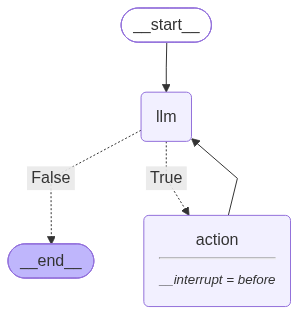

In [8]:
from IPython.display import Image, display

print("\n--- Tentando gerar PNG do grafo via Mermaid ---")
try:
    image_data = abot.graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))
except AttributeError:
    print("Método `.draw_mermaid_png()` não encontrado ou não suportado.")
    print("Tentando gerar apenas o código Mermaid...")
    try:
        mermaid_code = abot.graph.get_graph().draw_mermaid()
        print("\n--- Código Mermaid (cole em https://mermaid.live/) ---")
        print(mermaid_code)
    except Exception as e_mermaid:
        print(f"Erro ao gerar código Mermaid: {e_mermaid}")
except Exception as e:
    print(f"Erro inesperado ao tentar gerar o grafo: {e}")

## 10. HITL — aprovação humana da ação

O agente decide chamar a ferramenta e **pausa**. Aí ele te pergunta `sim/não`. Só se você aprovar é que a ação é executada.

In [9]:
session_id = str(uuid.uuid4())
print(f"DEBUG: Iniciando nova conversa com ID: {session_id}\n")

user_message = "Como está o tempo em São Paulo hoje?"
messages = [HumanMessage(content=user_message)]
thread_config = {"configurable": {"thread_id": session_id}}

print("--- Etapa 1: Agente processa a entrada e decide a ação ---")
print(f"Você: {user_message}")

for event in abot.graph.stream({"messages": messages}, thread_config):
    for k, v in event.items():
        if k == "llm":
            last_message = v.get('messages', [])[-1]
            if isinstance(last_message, AIMessage) and last_message.tool_calls:
                print(f"\nAgente (decisão): {last_message.tool_calls}")
                print("\n--- AGENTE PAUSADO: Intervenção Humana Necessária ---")
            else:
                print(f"\nAgente (resposta direta/sem tool_calls): {last_message.content}")
                print("\n--- AGENTE PAUSADO (resposta direta, sem ação pendente) ---")

current_state = abot.graph.get_state(thread_config)
last_state_message = current_state.values['messages'][-1]

if current_state and current_state.next == ('action',) and isinstance(last_state_message, AIMessage) and last_state_message.tool_calls:
    tool_calls_pending = last_state_message.tool_calls
    if tool_calls_pending:
        print("\nO agente decidiu executar a(s) seguinte(s) ação(ões) de ferramenta:")
        for tc in tool_calls_pending:
            print(f"- Ferramenta: {tc['name']}, Argumentos: {tc['args']}")

        user_input = input("\nVocê deseja que o agente execute esta(s) ação(ões)? (sim/não): ").lower()

        if user_input == 'sim':
            print("\n--- Etapa 2: Retomando a execução (Agente executará a ação) ---")
            for event in abot.graph.stream(None, thread_config):
                for k, v in event.items():
                    if k == "action":
                        print(f"DEBUG: Ferramenta executada e resultado retornado: {v}")
                    elif k == "llm":
                        final_response_message = v.get('messages', [])[-1].content
                        print(f"\nAgente (resposta final): {final_response_message}")
                    elif k == END:
                        print(f"DEBUG: Grafo terminou a execução.")
            print("\n--- FIM DA INTERAÇÃO ---")
        else:
            print("\nExecução da ação cancelada pelo usuário.")
            print("--- FIM DA INTERAÇÃO ---")
    else:
        print("\nO agente não decidiu nenhuma ação de ferramenta apesar da pausa. Interação encerrada.")
else:
    print("\nO agente respondeu diretamente ou não pausou em uma ação. Não há ações pendentes para aprovar.")
    if current_state:
        final_response_message = current_state.values['messages'][-1].content
        print(f"Agente (resposta direta): {final_response_message}")
    print("--- FIM DA INTERAÇÃO ---")

DEBUG: Iniciando nova conversa com ID: 16a6dbde-c249-4669-a980-1510e8fad71d

--- Etapa 1: Agente processa a entrada e decide a ação ---
Você: Como está o tempo em São Paulo hoje?

Agente (decisão): [{'name': 'tavily_search', 'args': {'query': 'tempo em São Paulo 02/10/2026', 'search_depth': 'fast', 'time_range': 'day'}, 'id': 'fc_e4bc9d8d-d00a-4caf-ac87-13fc9eddc46e', 'type': 'tool_call'}]

--- AGENTE PAUSADO: Intervenção Humana Necessária ---

O agente decidiu executar a(s) seguinte(s) ação(ões) de ferramenta:
- Ferramenta: tavily_search, Argumentos: {'query': 'tempo em São Paulo 02/10/2026', 'search_depth': 'fast', 'time_range': 'day'}

Você deseja que o agente execute esta(s) ação(ões)? (sim/não): SIM

--- Etapa 2: Retomando a execução (Agente executará a ação) ---
Chamando ferramenta: tavily_search com argumentos: {'query': 'tempo em São Paulo 02/10/2026', 'search_depth': 'fast', 'time_range': 'day'}
Voltando para o modelo!
DEBUG: Ferramenta executada e resultado retornado: {'messa

## 11. Segunda interação — inspecionando o estado pausado

Aqui iniciamos outra conversa e **olhamos o snapshot** do estado no momento da pausa, confirmando que existe uma `tool_call` pendente pronta para intervenção.

In [10]:
new_session_id = str(uuid.uuid4())
print(f"DEBUG: Iniciando nova conversa com ID: {new_session_id}\n")
new_user_message = "Qual é a distância entre o Rio de Janeiro e Tóquio?"
new_messages = [HumanMessage(content=new_user_message)]
new_thread_config = {"configurable": {"thread_id": new_session_id}}

print("--- Iniciando NOVA Interação: Agente processa a entrada e decide a ação ---")
print(f"Você: {new_user_message}")
print(f"DEBUG: Nova Thread ID: {new_session_id}")

print("\n--- Agente pensando e pausando ---")
try:
    for event in abot.graph.stream({"messages": new_messages}, new_thread_config):
        for k, v in event.items():
            if k == "llm":
                if v and 'messages' in v and v['messages']:
                    llm_message_from_event = v['messages'][0]
                    if hasattr(llm_message_from_event, 'tool_calls') and llm_message_from_event.tool_calls:
                        print(f"\nAgente (decisão): {llm_message_from_event.tool_calls}")
                        print("\n--- AGENTE PAUSADO: Intervenção Humana Necessária ---")
                    elif llm_message_from_event.content:
                        print(f"\nAgente (resposta direta): {llm_message_from_event.content}")
                        print("\n--- AGENTE NÃO PAUSOU PARA FERRAMENTA (Resposta direta do LLM) ---")
except Exception as e:
    print(f"DEBUG: Stream interrompido como esperado: {e}")

current_state_snapshot = abot.graph.get_state(new_thread_config)

if current_state_snapshot:
    print(f"\nDEBUG: Estado atual obtido para NOVA thread ID: {new_session_id}")

    snapshot_thread_id = None
    snapshot_thread_ts = None

    if hasattr(current_state_snapshot, 'config') and isinstance(current_state_snapshot.config, dict):
        if 'configurable' in current_state_snapshot.config and isinstance(current_state_snapshot.config['configurable'], dict):
            if 'thread_id' in current_state_snapshot.config['configurable']:
                snapshot_thread_id = current_state_snapshot.config['configurable']['thread_id']
            if '__run_id' in current_state_snapshot.config['configurable']:
                snapshot_thread_ts = current_state_snapshot.config['configurable']['__run_id']
            elif 'thread_ts' in current_state_snapshot.config['configurable']:
                snapshot_thread_ts = current_state_snapshot.config['configurable']['thread_ts']

    if snapshot_thread_id is None:
        snapshot_thread_id = new_session_id

    print(f"DEBUG: ID da Thread (do snapshot): {snapshot_thread_id}")
    print(f"DEBUG: Timestamp do snapshot (thread_ts): {snapshot_thread_ts}")
    print(f"DEBUG: Mensagens no snapshot (no momento da pausa): {current_state_snapshot.values.get('messages')}")

    if current_state_snapshot.values and 'messages' in current_state_snapshot.values:
        last_msg_in_snapshot = current_state_snapshot.values['messages'][-1]
        print(f"DEBUG: Tipo da última mensagem no snapshot para injeção: {type(last_msg_in_snapshot)}")
        if hasattr(last_msg_in_snapshot, 'tool_calls') and last_msg_in_snapshot.tool_calls:
            print(f"DEBUG: Última mensagem no snapshot TEM tool_calls. PRONTO PARA INJEÇÃO!")
        else:
            print(f"DEBUG: Última mensagem no snapshot NÃO TEM tool_calls ou está vazia. PROBLEMA NA PAUSA!")
    if current_state_snapshot.next != ():
        print("\n--- Agente está PAUSADO e pronto para intervenção. ---")
    else:
        print("\n--- ATENÇÃO: O agente NÃO está pausado onde esperávamos. O grafo pode ter terminado. ---")
else:
    print(f"DEBUG: Nenhum estado encontrado para a nova thread ID: {new_session_id}.")

DEBUG: Iniciando nova conversa com ID: 86f5f508-5c97-4067-a26d-a79292e5d542

--- Iniciando NOVA Interação: Agente processa a entrada e decide a ação ---
Você: Qual é a distância entre o Rio de Janeiro e Tóquio?
DEBUG: Nova Thread ID: 86f5f508-5c97-4067-a26d-a79292e5d542

--- Agente pensando e pausando ---

Agente (resposta direta): A distância aérea (ou “como‑o‑corvo voa”) entre o Rio de Janeiro (Aeroporto Internacional do Rio‑Galeão – GIG) e Tóquio (Aeroporto Internacional de Narita – NRT ou Aeroporto de Haneda – HND) é aproximadamente **18 600 km** (cerca de **11 570 milhas**).  

Essa medida corresponde à menor distância ao longo da superfície da Terra (a chamada “great‑circle distance”) e pode variar ligeiramente dependendo do ponto exato de partida/chegada usado nos cálculos.  

Se precisar de rotas comerciais, a maioria dos voos faz conexão em hubs como São Paulo, Dallas/Fort Worth, Dubai ou Doha, o que aumenta o percurso total em algumas centenas de quilômetros.

--- AGENTE NÃO 

## 12. Intervenção manual — injetando uma resposta no estado

Em vez de deixar o agente executar a ferramenta, nós **substituímos** a resposta manualmente (simulando um humano assumindo o controle) e finalizamos com `update_state`.

In [11]:
if current_state_snapshot:
    modified_state_values = current_state_snapshot.values.copy()

    final_injected_message = AIMessage(
        content="A distância entre o Rio de Janeiro e Tóquio é de aproximadamente 18.500 km. (Dados fornecidos MANUALMENTE por você!)"
    )
    ai_message_found = False
    for i, msg in enumerate(modified_state_values['messages']):
        if isinstance(msg, AIMessage):
            modified_state_values['messages'] = modified_state_values['messages'][:i] + [final_injected_message]
            ai_message_found = True
            break

    if not ai_message_found:
        modified_state_values['messages'].append(final_injected_message)

    print("\n--- Estado sendo MODIFICADO MANUALMENTE (Injetando AIMessage Final) ---")
    print(f"DEBUG: Conteúdo da AIMessage injetada: {final_injected_message.content}")
    print(f"DEBUG: Nova lista de mensagens (últimas): {[m.type for m in modified_state_values['messages'][-2:]]}")
else:
    print("DEBUG: Não é possível modificar o estado porque nenhum snapshot foi encontrado.")


--- Estado sendo MODIFICADO MANUALMENTE (Injetando AIMessage Final) ---
DEBUG: Conteúdo da AIMessage injetada: A distância entre o Rio de Janeiro e Tóquio é de aproximadamente 18.500 km. (Dados fornecidos MANUALMENTE por você!)
DEBUG: Nova lista de mensagens (últimas): ['human', 'ai']


In [12]:
print("\n--- Finalizando o estado com a resposta injetada ---")

abot.graph.update_state(new_thread_config, modified_state_values)

final_state_after_injection_obj = abot.graph.get_state(new_thread_config)

print("\n--- Saída final do agente após intervenção ---")

if hasattr(final_state_after_injection_obj, 'values') and isinstance(final_state_after_injection_obj.values, dict):
    final_messages = final_state_after_injection_obj.values['messages']
elif isinstance(final_state_after_injection_obj, dict):
    final_messages = final_state_after_injection_obj['messages']
else:
    found_messages_list = None
    if isinstance(final_state_after_injection_obj, tuple):
        for item in final_state_after_injection_obj:
            if isinstance(item, dict) and 'messages' in item:
                found_messages_list = item['messages']
                break
    elif isinstance(final_state_after_injection_obj, dict) and 'messages' in final_state_after_injection_obj:
        found_messages_list = final_state_after_injection_obj['messages']

    if found_messages_list is not None:
        final_messages = found_messages_list
    else:
        print(f"DEBUG: Não foi possível extrair as mensagens: {final_state_after_injection_obj}")
        final_messages = []

if final_messages and isinstance(final_messages[-1], AIMessage):
    print(f"\nAgente: {final_messages[-1].content}")
else:
    print("\nAgente: Resposta final não encontrada ou não é um AIMessage.")
    print(f"DEBUG: Estado final completo: {final_state_after_injection_obj}")

print("\n--- Fluxo de Human-in-the-Loop concluído ---")


--- Finalizando o estado com a resposta injetada ---

--- Saída final do agente após intervenção ---

Agente: A distância entre o Rio de Janeiro e Tóquio é de aproximadamente 18.500 km. (Dados fornecidos MANUALMENTE por você!)

--- Fluxo de Human-in-the-Loop concluído ---
